# Exercise - Monte Carlo Uncertainty Propagation

In [69]:
from collections.abc import Sequence
import numpy as np
import matplotlib.pyplot as plt

def is_sequence_or_array(a):
    return isinstance(a, Sequence) or isinstance(a, np.ndarray)

def excess_kurtosis(x):
    x_bar = np.mean(x)

    return np.mean((x - x_bar)**4) / np.mean((x - x_bar)**2)**2 - 3

def excess_kurtosis_unbiased(x):
    return (x.size - 1) * ( (x.size + 1) * excess_kurtosis(x) + 6) / (x.size - 2) / (x.size - 3)

# Random number generators
rng = np.random.default_rng()

def random_uniform(x, u_x, M):
    '''Wrapper for the uniform random number generator using more convenient arguments'''
    
    id = np.ones((M, x.size)) if is_sequence_or_array(x) else np.ones(M)
    
    a = np.sqrt(3) * u_x
    low = (x - a) * id
    high = (x + a) * id

    return rng.uniform(low=low, high=high).T

def random_triangular(x, u_x, M):
    '''Wrapper for the triangular random number generator using more convenient arguments'''
    id = np.ones((M, x.size)) if is_sequence_or_array(x) else np.ones(M)
    
    a = np.sqrt(6) * u_x
    
    left = (x - a) * id
    mode = x * id
    right = (x + a) * id

    return rng.triangular(left=left, mode=mode, right=right).T

def random_norm(x, u_x, M):
    '''Wrapper for the normal random number generator using more convenient arguments'''
    id = np.ones((M, x.size)) if is_sequence_or_array(x) else np.ones(M)
    
    return rng.normal(loc=x * id, scale=u_x * id).T


# Functional forms of the PDFs (used for plotting)
def norm_dist(x, mean, sigma):
    return np.exp( -(x - mean) ** 2 / sigma / sigma ) / sigma / np.sqrt(2 * np.pi)

def uniform_dist(x, mean, a):
    return np.where((x > mean - a) & (x < mean + a), 0.5 / a, 0)

def triangle_dist(x, mean, a):
    dist = np.zeros_like(x)
    
    # Left side of triangle
    where_left = (x > mean - a) & (x <= mean)
    dist[where_left] = (x[where_left] - mean) / a / a + 1/a
    
    # Right side of triangle
    where_right = (x > mean) & (x < mean + a)
    dist[where_right] = (mean - x[where_right]) / a / a + 1/ a
    return dist


def mc_uncertainty(N_range, f_rand, f_y, f_u, M, k, p, print_vals=False):

    if not is_sequence_or_array(N_range):
        N_range = (N_range,)

    fig, axs = plt.subplots(len(N_range), 1, figsize=(6, 4 * len(N_range)))

    if not is_sequence_or_array(axs):
        axs = (axs,)

    axs[-1].set_xlabel('$y_r$')
    fig.suptitle(f'Distributions of $y_r$. Agreement Between Methods For {p} Level of Confidence')

    for N, ax in zip(N_range, axs):
        # x = np.arange(10, 10 * (N+1), 10)
        u_x = np.arange(1.0, N + 1)
        x = 10 * u_x

        x_r = f_rand(x, u_x, M)
        # x_r = np.zeros((x.size, M))

        # for i in range(M):
        #     x_r[:, i] = f_rand(x, u_x, None)
        y_r = f_y(*x_r)

        ax.hist(y_r, density=1.0)
        # ax.set_xlabel('$y_r$')
        ax.set_ylabel('Relative Frequency')

        #Does agree
        y_mc = np.mean(y_r)
        u_y_mc = np.std(y_r, ddof=1)

        y = f_y(*x)
        u_y = f_u(*u_x)
        
        d = np.abs(y - y_mc)
        u_d = np.sqrt(u_y * u_y + u_y_mc * u_y_mc)
        
        if d < k * u_d:
            ax.set_title(f'$N={N}$ (Agree)')
        else:
            ax.set_title(f'$N={N}$ (Don\'t Agree)')
        

        if print_vals:
            print('Monte Carlo Method:')
            print('y =', y_mc)
            print('u(y) =', u_y_mc)
            
            print('Direct Calculation:')
            print('y =', y)
            print('u(y) =', u_y)
        
            if d < k * u_d:
                print(f'Methods agree with {p} level of confidence.')
            else:
                print(f'Methods don\'t agree with {p} level of confidence.')
    
    return fig, ax

In [37]:
isinstance(np.array((1, 2, 3)), Sequence)

False

In [32]:
M = 10
x = 2

np.ones((M, x.size)) if isinstance(x, Sequence) else np.ones(M)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [31]:
N = 4
M = 10

low = np.arange(0, N)
high = np.arange(1, N+1)

low = low * np.ones((M, N))
high = high * np.ones((M, N))

rng.uniform(low=low, high=high).T

array([[0.74537392, 0.79247188, 0.73381895, 0.80022275, 0.65571729,
        0.98515276, 0.12374678, 0.28552137, 0.65809474, 0.6155369 ],
       [1.68901213, 1.27146091, 1.48927812, 1.25472155, 1.01609305,
        1.74748288, 1.59281001, 1.60378429, 1.63566888, 1.14206695],
       [2.00612247, 2.91605614, 2.59804662, 2.12532855, 2.45138484,
        2.76588795, 2.29564582, 2.09143914, 2.79923015, 2.93800253],
       [3.60377556, 3.10891173, 3.98960736, 3.49530413, 3.25376882,
        3.24771488, 3.13938083, 3.47611791, 3.09737162, 3.09197025]])

## Question 1

Monte Carlo Method:
y = 100.00468496146205
u(y) = 5.477472056541735
Direct Calculation:
y = 100.0
u(y) = 5.477225575051661
Methods agree with 68.27% level of confidence.


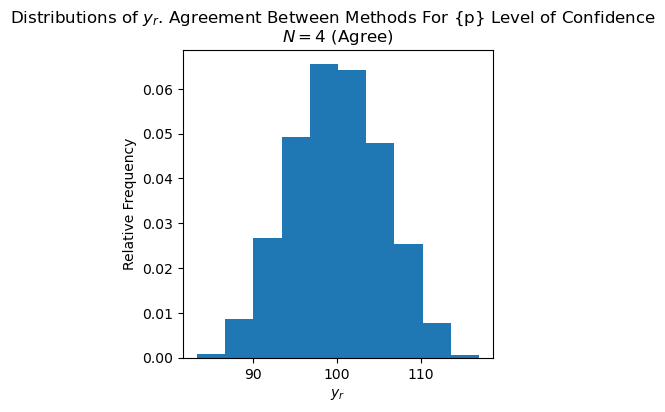

In [46]:
k = 1
p = '68.27%'
M = int(1e6)
N = 4

def y_linear(*x):
    return np.sum(x, axis=0)

def u_y_linear(*u_x):
    u_x = np.array(u_x)
    return np.sqrt(np.sum(u_x * u_x, axis=0))

fig, ax = mc_uncertainty(N, random_uniform, y_linear, u_y_linear, M, k, p, print_vals=True)
plt.show()
fig.clear()

## Question 2

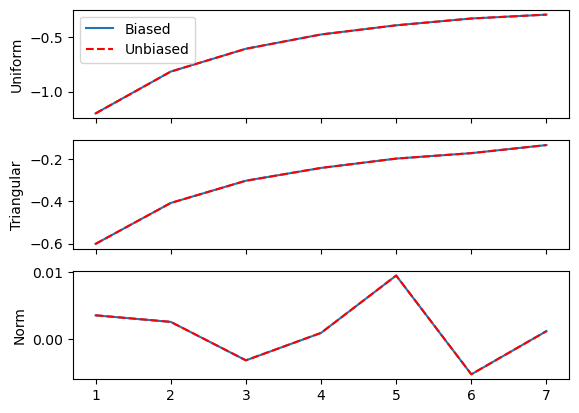

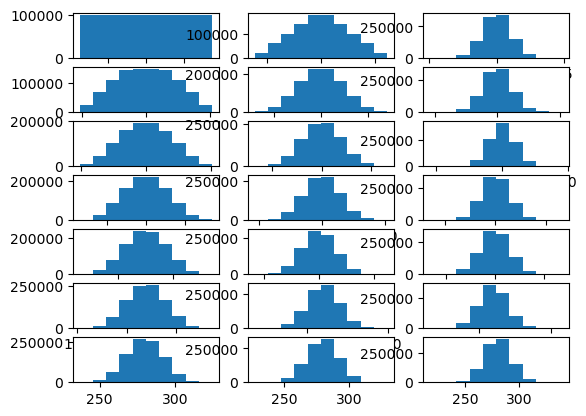

In [73]:
N_range = np.arange(1, 8, dtype=int)
M = int(1e6)

# ek = np.zeros((3, N_range.size))

fig_kurt, ax_kurt = plt.subplots(3, 1, sharex=True)
fig_dist, ax_dist = plt.subplots(N_range.size, 3)

for i, (f_rand, lbl) in enumerate(zip(
    (random_uniform, random_triangular, random_norm),
    ('Uniform', 'Triangular', 'Norm')
)):
    kurt = np.zeros(N_range.size, dtype=float)
    kurt_unbiased = np.zeros(N_range.size, dtype=float)

    for j, N in enumerate(N_range):
        u_x = np.arange(1.0, N + 1)
        x = 10 * u_x

        x_r = f_rand(x, u_x, M)
        y_r = y_linear(*x_r)
        
        kurt[j] = excess_kurtosis(y_r)
        kurt_unbiased[j] = excess_kurtosis_unbiased(y_r)

        ax_dist[j][i].hist(y_r)

    ax_kurt[i].plot(N_range, kurt, label='Biased')
    ax_kurt[i].plot(N_range, kurt_unbiased, 'r--', label='Unbiased')
    ax_kurt[i].set_ylabel(lbl)

ax_kurt[0].legend()

plt.show()


In [68]:
excess_kurtosis(y_r)

##Depreciated

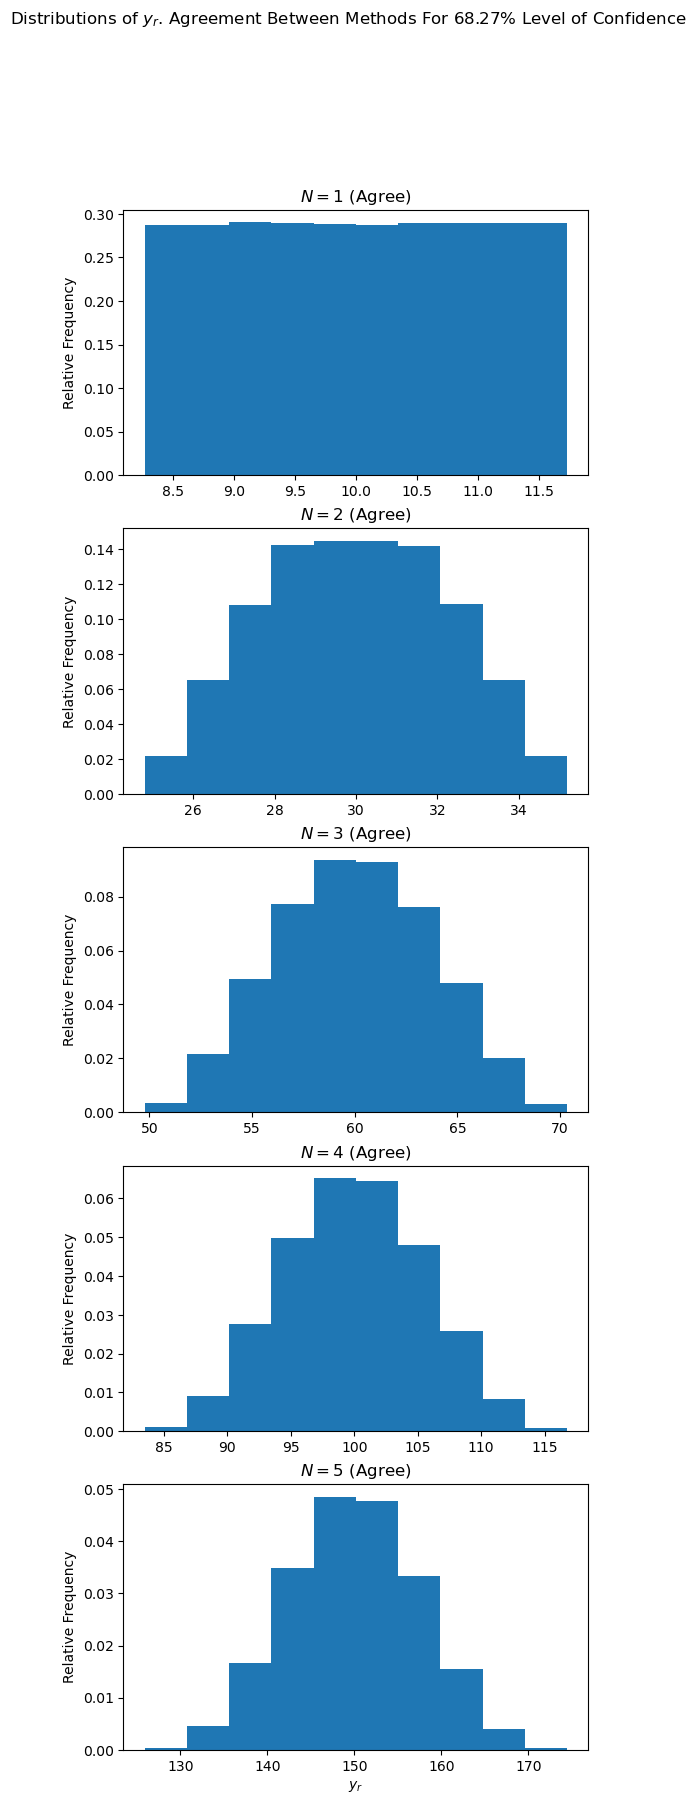

In [ ]:
k = 1
p = '68.27%'
M = int(1e6)
N = np.arange(1, 6, 1)

def y_linear(*x):
    return np.sum(x, axis=0)

def u_y_linear(*u_x):
    u_x = np.array(u_x)
    return np.sqrt(np.sum(u_x * u_x, axis=0))

fig, ax = mc_uncertainty(N, random_uniform, y_linear, u_y_linear, M, k, p)
plt.show()
fig.clear()

## Question 3

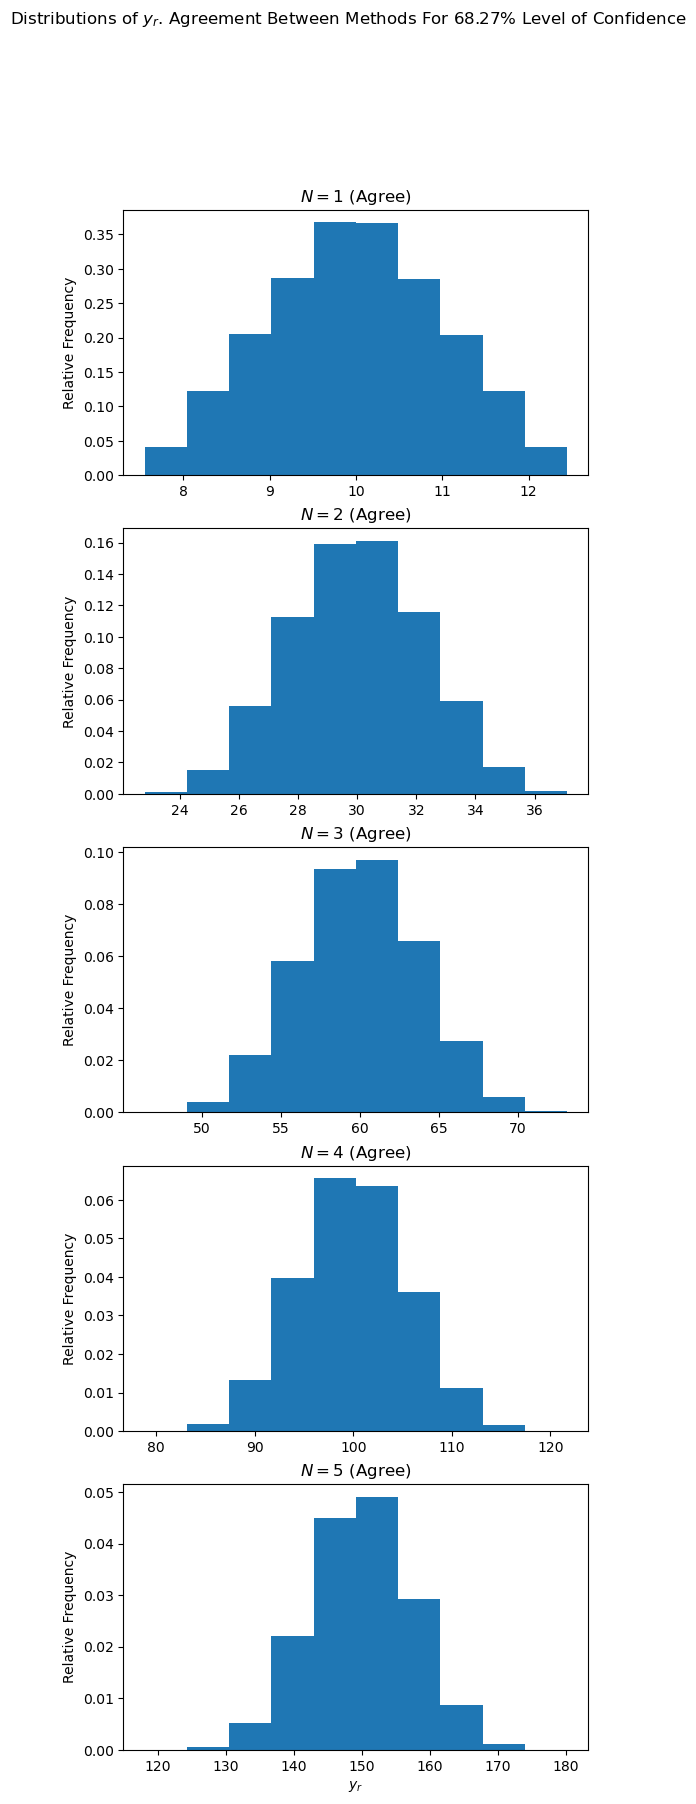

In [54]:
k = 1
p = '68.27%'
M = int(1e6)
N = np.arange(1, 6, 1)

def y_linear(*x):
    return np.sum(x, axis=0)

def u_y_linear(*u_x):
    u_x = np.array(u_x)
    return np.sqrt(np.sum(u_x * u_x, axis=0))

fig, ax = mc_uncertainty(N, random_triangular, y_linear, u_y_linear, M, k, p)
plt.show()
fig.clear()

## Question 4

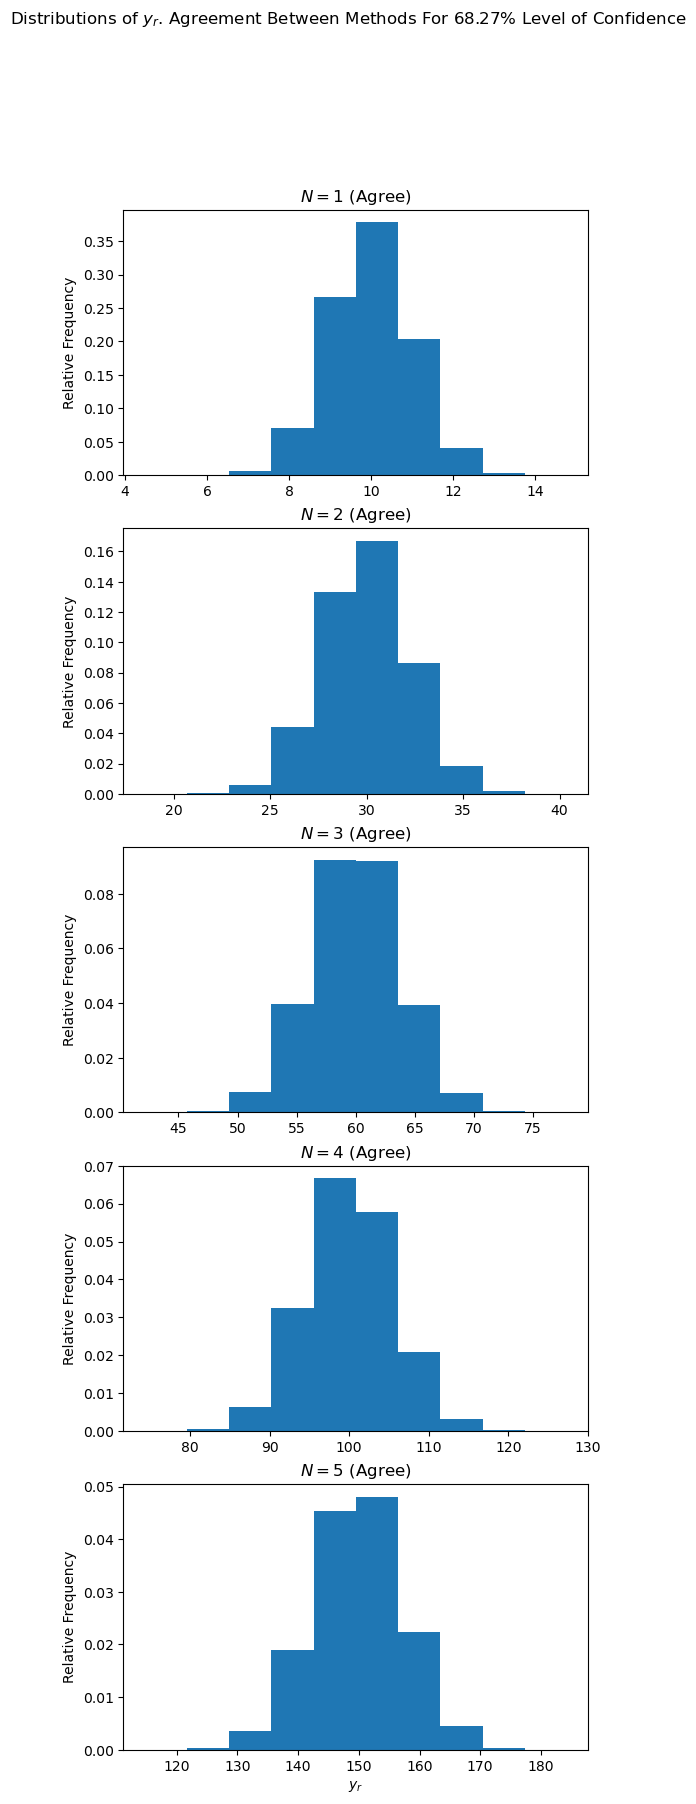

In [57]:
k = 1
p = '68.27%'
M = int(1e6)
N = np.arange(1, 6, 1)

def y_linear(*x):
    return np.sum(x, axis=0)

def u_y_linear(*u_x):
    u_x = np.array(u_x)
    return np.sqrt(np.sum(u_x * u_x, axis=0))

fig, ax = mc_uncertainty(N, random_norm, y_linear, u_y_linear, M, k, p)
plt.show()
fig.clear()